In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\User HP\Downloads\diabetes.csv")

In [3]:
df.head(8)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0


In [4]:
df.shape

(768, 9)

In [5]:
print(df.dtypes)
# connaitre le type des variables 

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [6]:
print(df.isnull().sum())
# connaitre les variables qui comportent les zeros

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
print((df == 0).sum())
# cest pour compter le nombre de zero de chaque attribut

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


In [8]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].mean())
# pour remplacer les faux zeros

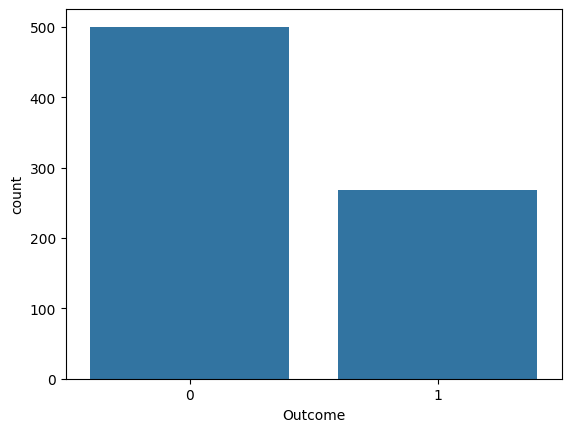

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df)
plt.show()
# savoir combien de personnes ont le diabete et combien de personnes ne l'ont pas

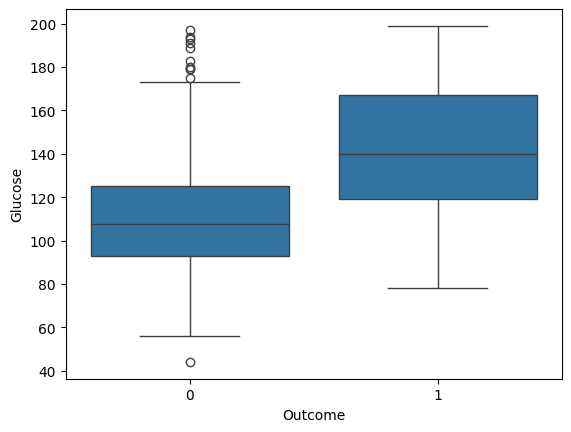

In [10]:
sns.boxplot(x="Outcome", y="Glucose", data=df)
plt.show()
# le glucose est souvent la variable la plus importante quand on cherche le diabete
# les diabetique ont souvemt un taux de glucose plus eleve 

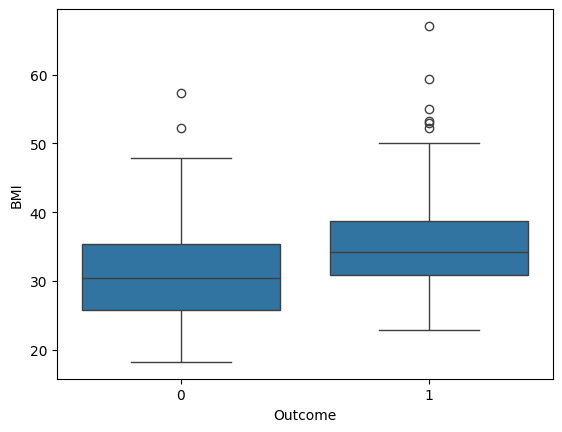

In [11]:
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.show()
#pour savoir si ceux qui ont le diabete ont une IMC plus eleve

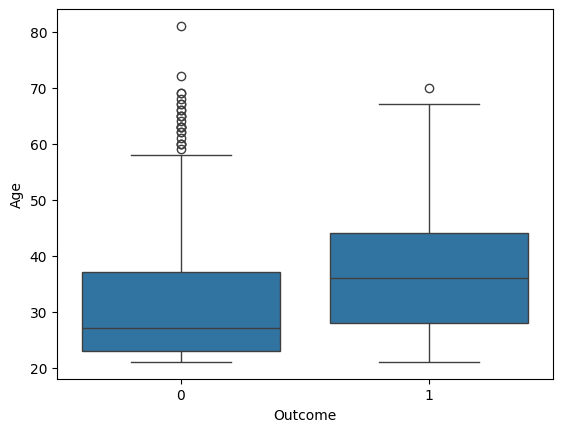

In [12]:
sns.boxplot(x="Outcome", y="Age", data=df)
plt.show()
# pour savoir si le diabete augmente avec l'age

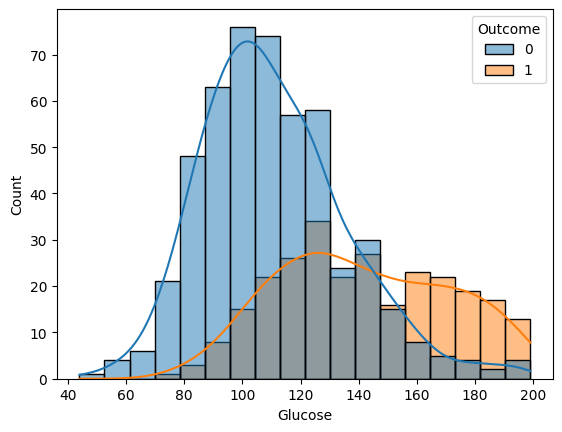

In [13]:
sns.histplot(data=df,
             x="Glucose",
             hue="Outcome",
             kde=True)

plt.show()
# savoir ou se concentre les patients diabetiques

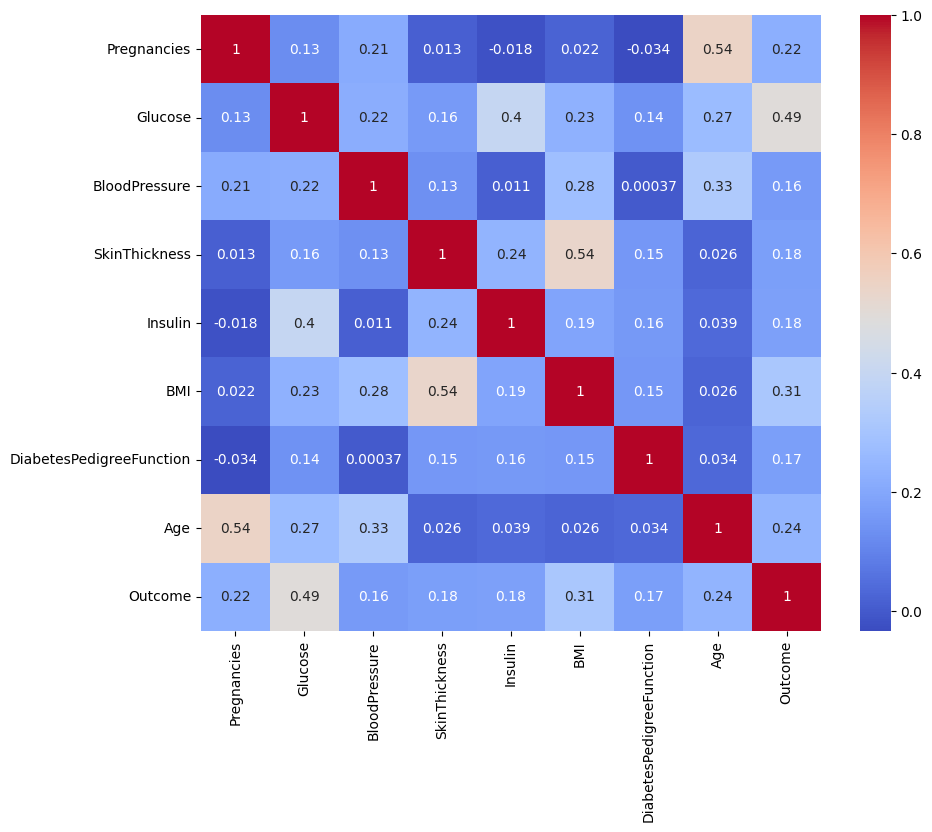

In [14]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

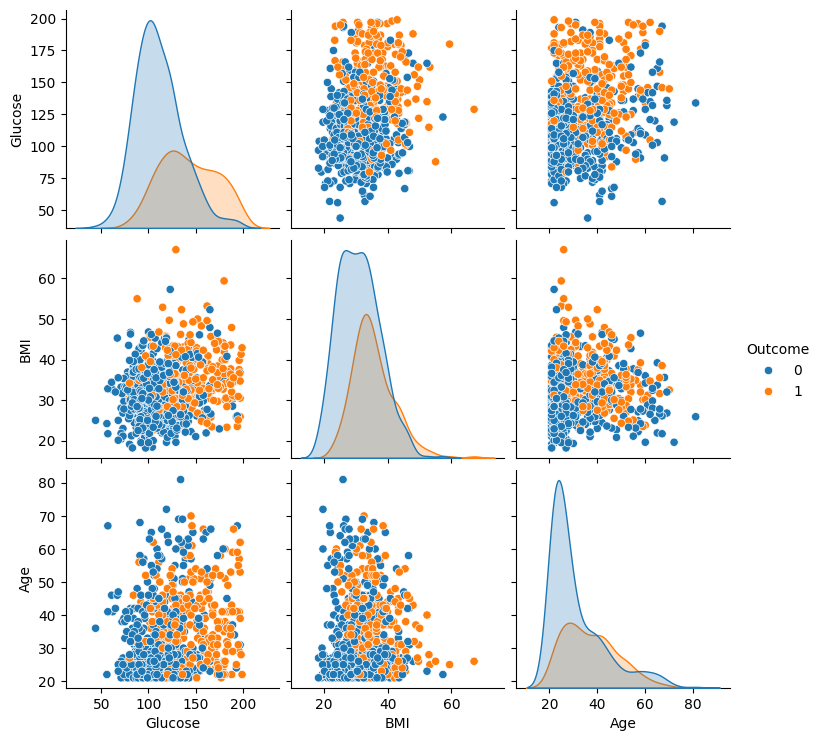

In [15]:
sns.pairplot(df,
             vars=["Glucose",
                   "BMI",
                   "Age"],
             hue="Outcome")

plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier()

start = time.time()

model.fit(X_train, y_train)

end = time.time()

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Temps d'exécution :", end - start)

Accuracy : 0.7272727272727273
Temps d'exécution : 0.01105189323425293


In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[71 28]
 [14 41]]


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.72      0.77        99
           1       0.59      0.75      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.73       154



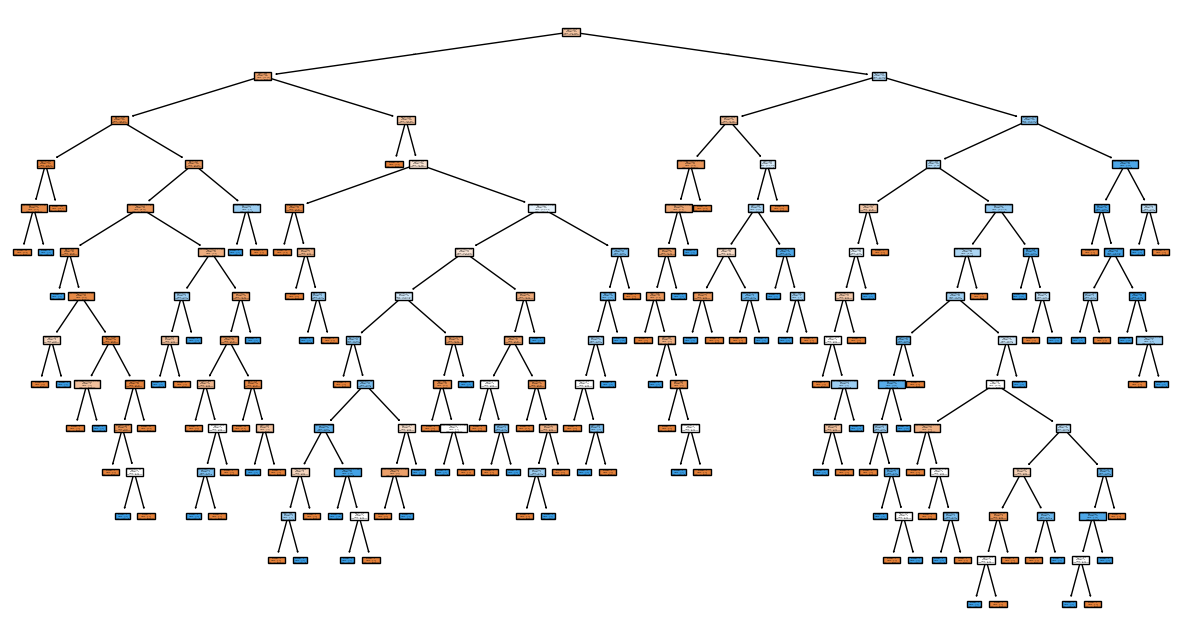

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Non diabétique","Diabétique"],
    filled=True
)

plt.show()

In [20]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False)

Glucose                     0.328442
BMI                         0.150063
Age                         0.136581
DiabetesPedigreeFunction    0.112053
BloodPressure               0.085796
Insulin                     0.072626
SkinThickness               0.070986
Pregnancies                 0.043454
dtype: float64

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Variables explicatives
X = df.drop("Outcome", axis=1)

# Variable cible
y = df["Outcome"]

# Découpage train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardisation
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modèle KNN
model = KNeighborsClassifier(n_neighbors=5)

# Entraînement
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.7662337662337663
